In [21]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn Modules
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Models
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# Set display options
sns.set_theme(style = "whitegrid")
%matplotlib inline

In [22]:
# Load the cleaned dataset in notebook 01
df = pd.read_csv("clean_resume_dataset.csv")

In [23]:
df.head()

,Category,File_Path,Resume,Clean_Resume,Resume_Length
0,Peoplesoft Resume,P637 Dataset/Resumes_Docx/Peoplesoft Resume/Pe...,Anubhav Kumar Singh\t\t\n\n To work in a gl...,anubhav kumar singh work globally competitive ...,5729
1,Peoplesoft Resume,P637 Dataset/Resumes_Docx/Peoplesoft Resume/Pe...,Murali\n\nExperience Summary \n\nI have 6 year...,murali experience summary year experience work...,3163
2,Peoplesoft Resume,P637 Dataset/Resumes_Docx/Peoplesoft Resume/Pe...,\n\n\n\n\n\n\n\n\n\n\n\n\n\nPROFILE SUMMARY\n\...,profile summary overall year experience people...,2788
3,Peoplesoft Resume,P637 Dataset/Resumes_Docx/Peoplesoft Resume/Pe...,PeopleSoft Admin\nVARKALA VIKAS\n\nCareer Obj...,peoplesoft admin varkala vikas career objectiv...,5930
4,Peoplesoft Resume,P637 Dataset/Resumes_Docx/Peoplesoft Resume/Pe...,PeopleSoft Administration\n \nVivekanand Sayan...,peoplesoft administration vivekanand sayana ca...,11609


In [24]:
df.shape

(53, 5)

In [25]:
# Ensure no missing values remain
df = df.dropna(subset = ['Clean_Resume', 'Category']).reset_index(drop = True)

In [26]:
# Label Encoding
# covert resume categories into numerical values
label_encoding = LabelEncoder()
df['Category_Encoded'] = label_encoding.fit_transform(df['Category'])

In [27]:
# Display mapping overview
mapping = dict(zip(label_encoding.classes_, label_encoding.transform(label_encoding.classes_)))
print(f"Total Unique Categories: {len(mapping)}")
df[['Category', 'Category_Encoded']].head()

Total Unique Categories: 4


,Category,Category_Encoded
0,Peoplesoft Resume,0
1,Peoplesoft Resume,0
2,Peoplesoft Resume,0
3,Peoplesoft Resume,0
4,Peoplesoft Resume,0


In [28]:
# TF-IDF Vectorization
# Initialize TF-IDF Vectorizer
tfidf = TfidfVectorizer(max_features = 3000)

# Fit and transform the processed resume text column
X = tfidf.fit_transform(df['Clean_Resume']).toarray()
y = df['Category_Encoded'].values

print("Feature matrix shape (X):", X.shape)
print("Target array shape (y):", y.shape)

Feature matrix shape (X): (53, 2976)
Target array shape (y): (53,)


In [29]:
# train-Test split
# Split dataset into 80% Training and 20% Testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape:  {X_test.shape}")

Training set shape: (42, 2976)
Testing set shape:  (11, 2976)


In [30]:
# Model Building (6 Algorithms)
# Define 6 classification algorithms
models = {
    'Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Support Vector Machine': SVC(kernel='linear', random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier()
}

# train models
trained_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"✅ {name} trained successfully.")

✅ Naive Bayes trained successfully.
✅ Logistic Regression trained successfully.
✅ Support Vector Machine trained successfully.
✅ Decision Tree trained successfully.
✅ Random Forest trained successfully.
✅ K-Nearest Neighbors trained successfully.


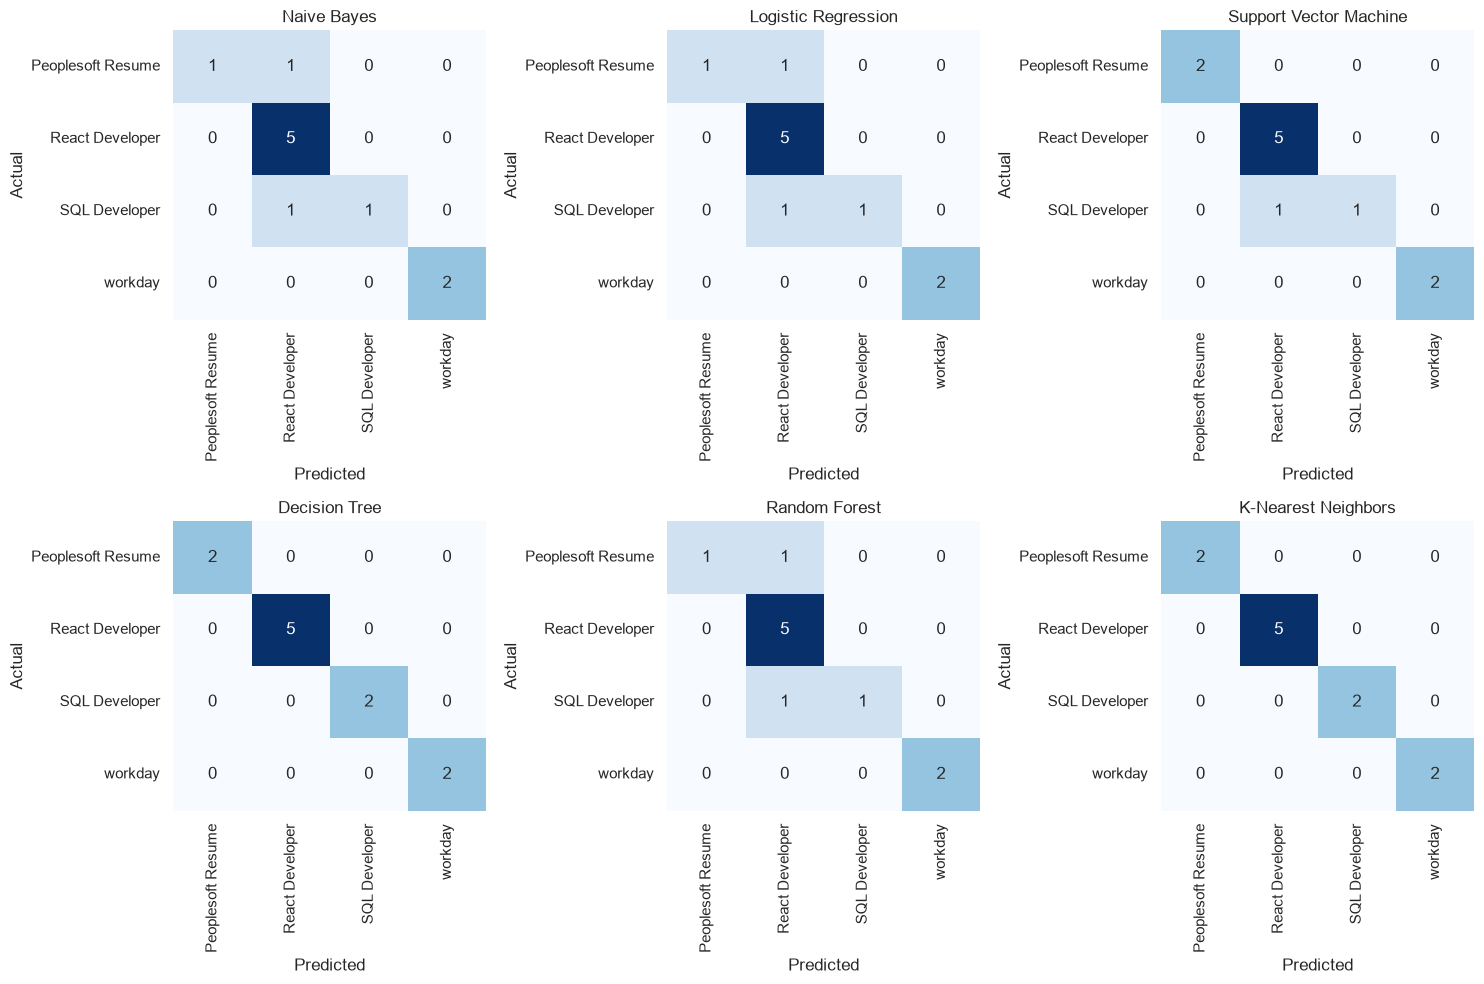

In [31]:
# Model Evaluation
results = []

plt.figure(figsize = (15, 10))

for idx, (name, model) in enumerate(trained_models.items(), 1):
    y_pred = model.predict(X_test)

    # Metrics calculation
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average = 'weighted')
    rec = recall_score(y_test, y_pred, average = 'weighted')
    f1 = f1_score(y_test, y_pred, average = 'weighted')

    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-score': f1
    })

    # Plot confusion matrix
    plt.subplot(2, 3, idx)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues', cbar = False,
                xticklabels = label_encoding.classes_,
                yticklabels = label_encoding.classes_)
    plt.title(f"{name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

plt.tight_layout()
plt.show()

In [32]:
# Model Comparison
# Create evaluation results DataFrame
df_results = pd.DataFrame(results).sort_values(by = 'F1-score', ascending = False).reset_index(drop = True)
print("--- Model Performance Ranking ---")
display(df_results)

--- Model Performance Ranking ---


,Model,Accuracy,Precision,Recall,F1-score
0,K-Nearest Neighbors,1.000000,1.000000,1.000000,1.000000
1,Decision Tree,1.000000,1.000000,1.000000,1.000000
2,Support Vector Machine,0.909091,0.924242,0.909091,0.898072
3,Naive Bayes,0.818182,0.870130,0.818182,0.803030
4,Logistic Regression,0.818182,0.870130,0.818182,0.803030
5,Random Forest,0.818182,0.870130,0.818182,0.803030


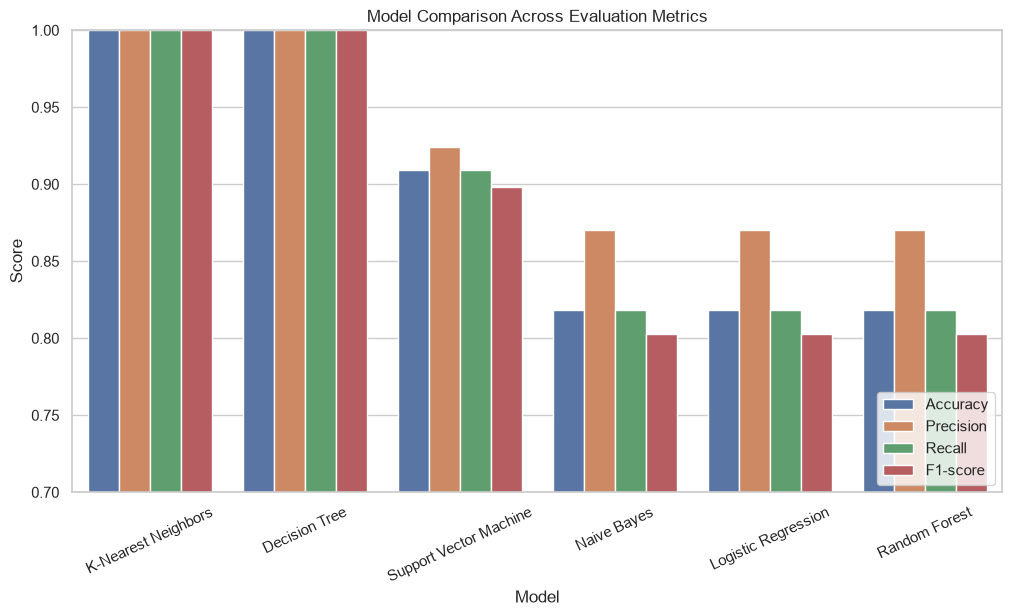

In [33]:
# Visualize matrics comparison
df_melted = df_results.melt(id_vars = "Model", var_name = "Metric", value_name = "Score")

plt.figure(figsize = (12, 6))
sns.barplot(data = df_melted, x = "Model", y = "Score", hue = "Metric")
plt.title("Model Comparison Across Evaluation Metrics")
plt.ylim(0.7, 1.0)
plt.xticks(rotation = 25)
plt.legend(loc = 'lower right')
plt.show()

In [34]:
# Identify the best model based on F1-score
best_model_name = df_results.loc[0, 'Model']
best_model = trained_models[best_model_name]
print(f"\n🏆 Best Performing Model: {best_model_name} (F1-score: {df_results.loc[0, 'F1-score']:.4f})")


🏆 Best Performing Model: K-Nearest Neighbors (F1-score: 1.0000)


In [35]:
# Save Artifacts (model.pkl, tfidf.pkl, label_encoder.pkl)
# Save the best model
with open('model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print("✅ Saved model.pkl successfully.")

✅ Saved model.pkl successfully.


In [36]:
# Save the fitted TF-IDF vectorizer
with open('tfidf.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

print("✅ Saved tfidf.pkl successfully.")

✅ Saved tfidf.pkl successfully.


In [37]:
# Save the fitted label encoder
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoding, f)

print("✅ Saved label_encoder.pkl successfully.")

✅ Saved label_encoder.pkl successfully.


In [38]:
# Verification (sanity check)
# Reload saved pickle artifacts and verify prediction pipeline
with open('model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

with open('tfidf.pkl', 'rb') as f:
    loaded_tfidf = pickle.load(f)

with open('label_encoder.pkl', 'rb') as f:
    loaded_le = pickle.load(f)

# Test on new samplt text
sample_text = ["Congratulations! You've won a $1,000 Walmart gift card. Click here to claim now."]
sample_vec = loaded_tfidf.transform(sample_text).toarray()
pred_encoded = loaded_model.predict(sample_vec)
pred_label = loaded_le.inverse_transform(pred_encoded)[0]

print("Sample Input:", sample_text[0])
print("Predicted Output:", pred_label)

Sample Input: Congratulations! You've won a $1,000 Walmart gift card. Click here to claim now.
Predicted Output: SQL Developer
